In [ ]:
#import required libraries for clustring
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pickle

In [ ]:
retail = pd.read_csv('OnlineRetail.csv', sep=",", encoding = "ISO-8859-1",header=0)

# New Section

In [ ]:
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [ ]:
retail.shape

(541909, 8)

In [ ]:
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## **Data Cleaning**

In [ ]:
#Calculating the missing values % contribution in DF
df_null=round((retail.isnull().sum()/len(retail))*100,2)
df_null

,0
InvoiceNo,0.00
StockCode,0.00
Description,0.27
Quantity,0.00
InvoiceDate,0.00
UnitPrice,0.00
CustomerID,24.93
Country,0.00


In [ ]:
#Dropping rows having missing values
retail=retail.dropna()
retail.shape

(406829, 8)

In [ ]:
#Changing the datatype of customer id
retail['CustomerID'] = retail['CustomerID'].astype(str)

**Feature Engineering (RFM)**


In [ ]:
#New Attribute : Monetary
retail['Amount'] = retail['Quantity'] * retail['UnitPrice']
rfm_m = retail.groupby('CustomerID')['Amount'].sum()
rfm_m = rfm_m.reset_index()
rfm_m.head()

,CustomerID,Amount
0,12346.0,0.00
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [ ]:
#New Attribute : Frequency
rfm_f = retail.groupby('CustomerID')['InvoiceNo'].count()
rfm_f = rfm_f.reset_index()
rfm_f.columns = ['CustomerID', 'Frequency']
rfm_f.head()

,CustomerID,Frequency
0,12346.0,2
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17


In [ ]:
#Merging above 2 dataframes
rfm = pd.merge(rfm_m, rfm_f, on='CustomerID', how='inner')
rfm.head()

,CustomerID,Amount,Frequency
0,12346.0,0.00,2
1,12347.0,4310.00,182
2,12348.0,1797.24,31
3,12349.0,1757.55,73
4,12350.0,334.40,17


In [ ]:
#New attribute: Recency
#Convert datetime to proper datatype
retail['InvoiceDate'] = pd.to_datetime(retail['InvoiceDate'],format='%d-%m-%Y %H:%M')


In [ ]:
# Compute the max date to know the last transaction date
max_date = max(retail['InvoiceDate'])
max_date

Timestamp('2011-12-09 12:50:00')

In [ ]:
#Compute the difference between the max date and transaction date
retail['Diff'] = max_date - retail['InvoiceDate']
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount,Diff
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,373 days 04:24:00
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,373 days 04:24:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00


In [ ]:
#Compute Recency of customer
rfm_p = retail.groupby('CustomerID')['Diff'].min()
rfm_p = rfm_p.reset_index()
rfm_p.columns = ['CustomerID', 'Recency']
rfm_p.head()

,CustomerID,Recency
0,12346.0,325 days 02:33:00
1,12347.0,1 days 20:58:00
2,12348.0,74 days 23:37:00
3,12349.0,18 days 02:59:00
4,12350.0,309 days 20:49:00


In [ ]:
# Extract number of days only
rfm_p['Recency'] = rfm_p['Recency'].dt.days
rfm_p.head()


,CustomerID,Recency
0,12346.0,325
1,12347.0,1
2,12348.0,74
3,12349.0,18
4,12350.0,309


In [ ]:
# Merge dataframes to get final RFM data frames
rfm = pd.merge(rfm, rfm_p, on='CustomerID', how='inner')
rfm.head()

,CustomerID,Amount,Frequency,Recency
0,12346.0,0.00,2,325
1,12347.0,4310.00,182,1
2,12348.0,1797.24,31,74
3,12349.0,1757.55,73,18
4,12350.0,334.40,17,309


**Outlier Detection**

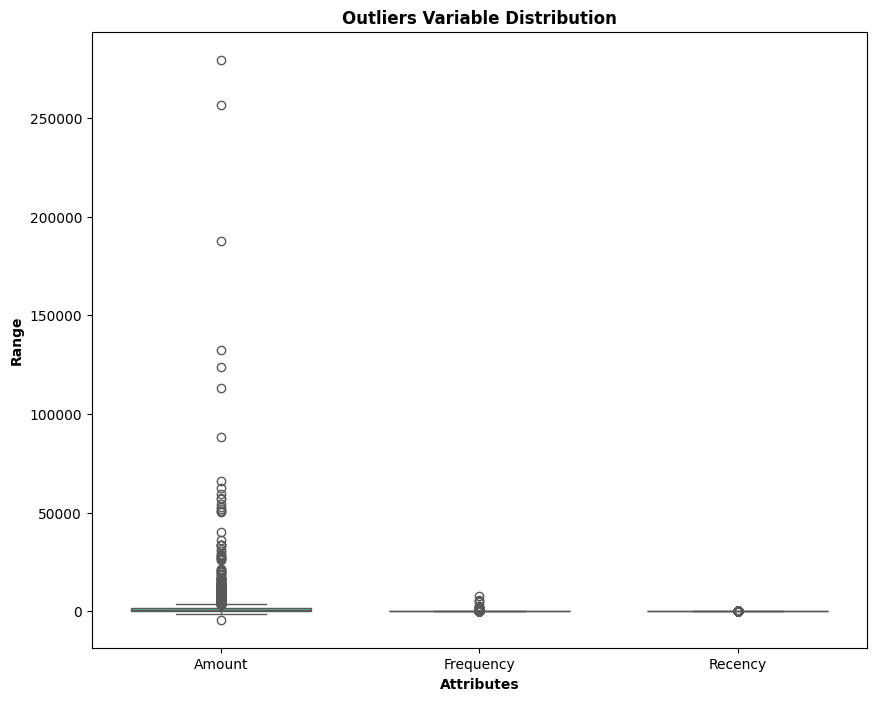

In [ ]:
attributes = ['Amount', 'Frequency', 'Recency']
plt.rcParams['figure.figsize'] = [10,8]
sns.boxplot(data = rfm[attributes], orient = 'v', palette = 'Set2', whis = 1.5, saturation = 1, width = 0.7)
plt.title("Outliers Variable Distribution", fontweight = 'bold')
plt.ylabel("Range", fontweight = 'bold')
plt.xlabel("Attributes", fontweight = 'bold')
plt.show()

In [ ]:
#Removing outliers for Amount
Q1 = rfm.Amount.quantile(0.05)
Q3 = rfm.Amount.quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm.Amount >= Q1 - 1.5*IQR) & (rfm.Amount <= Q3 + 1.5*IQR)]

#Removing outliers for Recency
Q1 = rfm.Recency.quantile(0.05)
Q3 = rfm.Recency.quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm.Recency >= Q1 - 1.5*IQR) & (rfm.Recency <= Q3 + 1.5*IQR)]

#Removing outliers for Frequency
Q1 = rfm.Recency.quantile(0.05)
Q3 = rfm.Recency.quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm.Frequency >= Q1 - 1.5*IQR) & (rfm.Frequency <= Q3 + 1.5*IQR)]

**Scaling the Features**

In [ ]:
rfm_df = rfm[['Amount','Frequency','Recency']]
#Instantiate
scaler = StandardScaler()
# fit_transform
rfm_df_scaled = scaler.fit_transform(rfm_df)
rfm_df_scaled.shape


(4296, 3)

In [ ]:
rfm_df_scaled = pd.DataFrame(rfm_df_scaled)

rfm_df_scaled.columns =['Amount','Frequency','Recency']

rfm_df_scaled.head()

,Amount,Frequency,Recency
0,-0.724074,-0.746158,2.302422
1,1.727712,1.022120,-0.905954
2,0.298304,-0.461269,-0.183079
3,0.275726,-0.048671,-0.737613
4,-0.533847,-0.598801,2.143984


Elbow Method

In [ ]:
wcss = []

for i in range(1,8):
    kmeans = KMeans(n_clusters=i, max_iter=50)
    kmeans.fit(rfm_df_scaled)
    wcss.append(kmeans.inertia_)


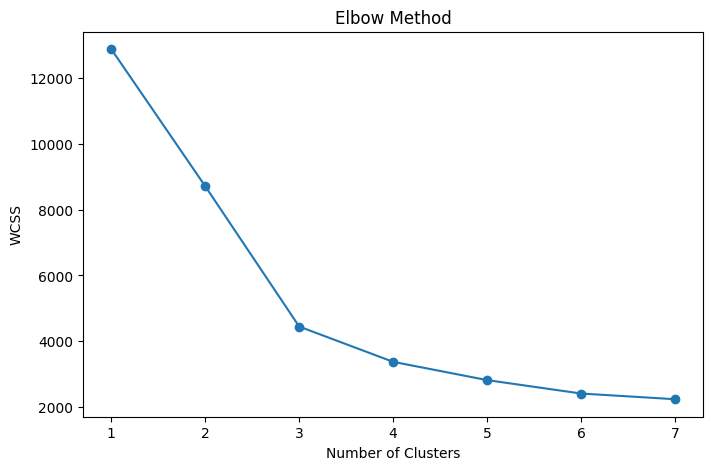

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1,8), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
#Final Model with k=3
kmeans = KMeans(n_clusters=3, max_iter=300)

kmeans.fit(rfm_df_scaled)

KMeans(n_clusters=3)

In [ ]:
rfm['Cluster'] = kmeans.labels_
rfm.head()

,CustomerID,Amount,Frequency,Recency,Cluster
0,12346.0,0.00,2,325,0
1,12347.0,4310.00,182,1,2
2,12348.0,1797.24,31,74,1
3,12349.0,1757.55,73,18,1
4,12350.0,334.40,17,309,0


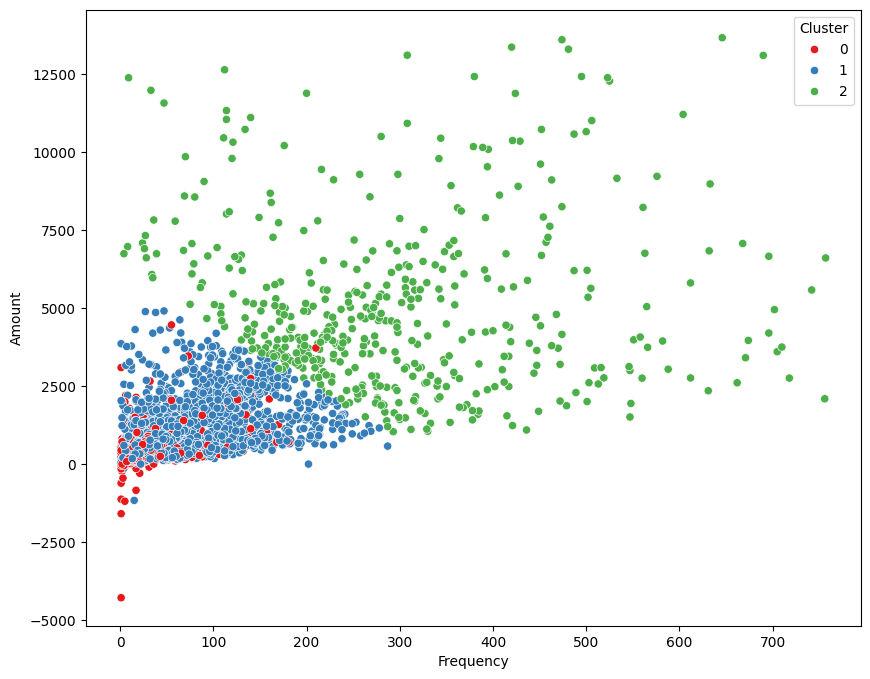

In [ ]:
sns.scatterplot(
    x=rfm['Frequency'],
    y=rfm['Amount'],
    hue=rfm['Cluster'],
    palette='Set1'
)
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(rfm_df_scaled)

kmeans_score = silhouette_score(rfm_df_scaled, kmeans_labels)
print("K-Means Silhouette Score:", kmeans_score)

K-Means Silhouette Score: 0.5093210537633415


In [ ]:
hc = AgglomerativeClustering(n_clusters=3)

hc_labels = hc.fit_predict(rfm_df_scaled)

hc_score = silhouette_score(rfm_df_scaled, hc_labels)
print("Hierarchical Silhouette Score:", hc_score)

Hierarchical Silhouette Score: 0.47130549882813416


In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(rfm_df_scaled)

dbscan_score = silhouette_score(rfm_df_scaled, dbscan_labels)
print("DBSCAN Silhouette Score:", dbscan_score)

DBSCAN Silhouette Score: 0.5989591832396569


In [ ]:
set(dbscan_labels)

{np.int64(-1),
 np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5)}

DBSCAN produced the highest silhouette score but generated multiple small clusters and noise points. Therefore, K-Means with 3 clusters was selected for better business interpretability.


In [ ]:
rfm['Cluster'].value_counts()

,count
Cluster,
1,2746
0,1069
2,481


In [ ]:
rfm.groupby('Cluster')[['Amount','Frequency','Recency']].mean()

,Amount,Frequency,Recency
Cluster,,,
0,388.204772,25.480823,248.188026
1,965.091596,60.548070,44.300073
2,4995.917963,293.945946,21.557173


In [ ]:
rfm['Segment'] = rfm['Cluster'].map({
0: 'Regular Customers',
1: 'High Value Customers',
2: 'Inactive Customers'
})

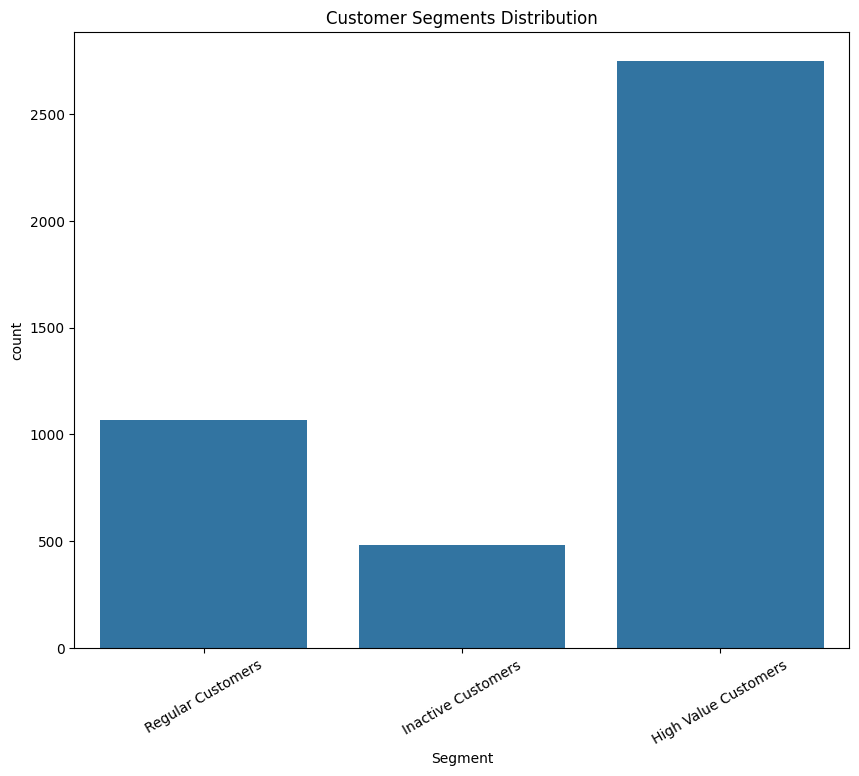

In [ ]:
sns.countplot(x='Segment', data=rfm)
plt.xticks(rotation=30)
plt.title("Customer Segments Distribution")
plt.show()

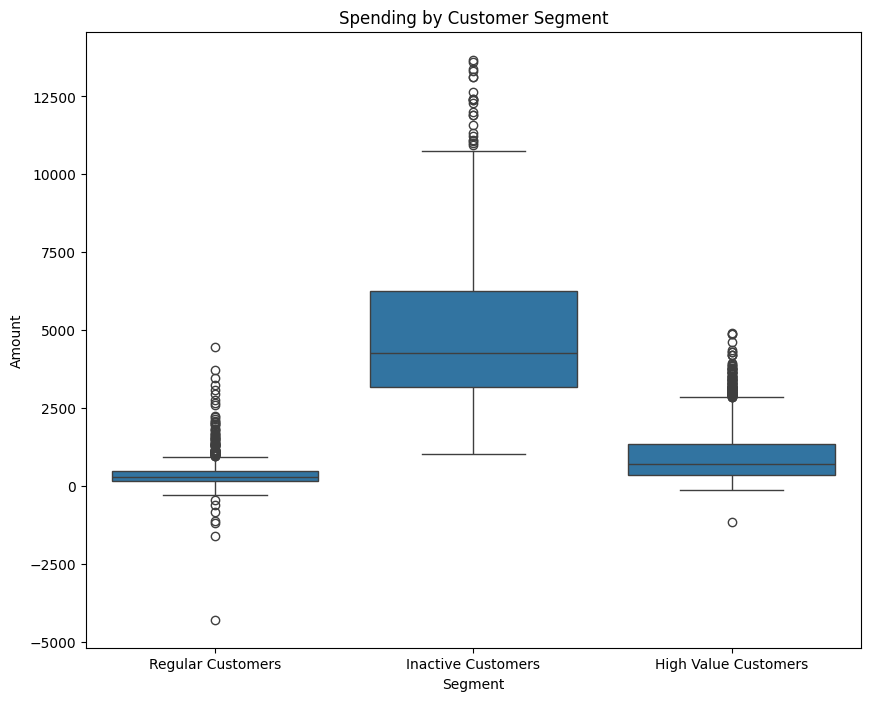

In [ ]:
#Spending Analysis
sns.boxplot(x='Segment', y='Amount', data=rfm)
plt.title("Spending by Customer Segment")
plt.show()

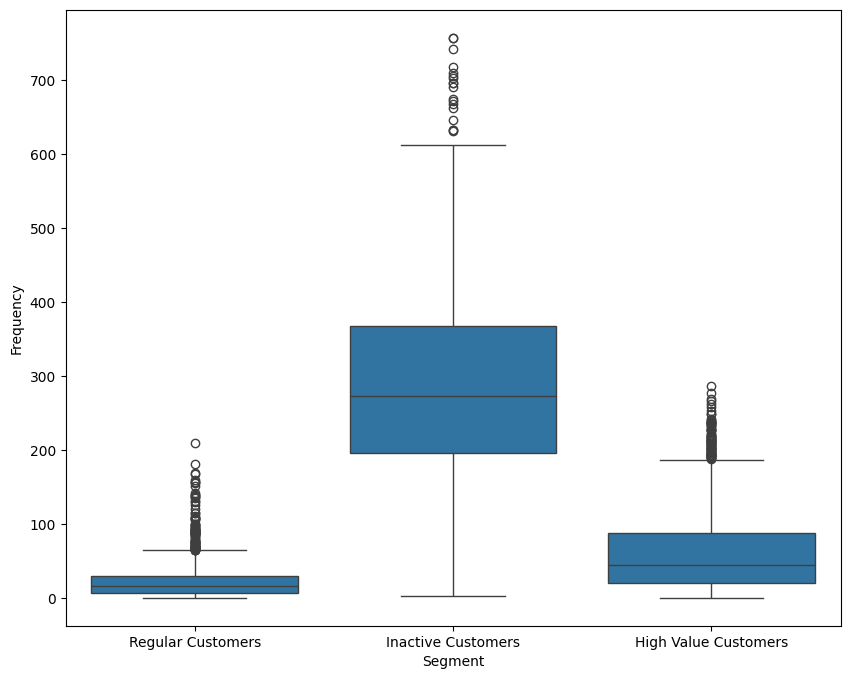

In [ ]:
#Frequency Analysis
sns.boxplot(x='Segment', y='Frequency', data=rfm)
plt.show()

Insight 1

High Value Customers have the highest purchase frequency and spending amount.

Insight 2

Inactive Customers show high recency, meaning they have not purchased for a long time.

Insight 3

Regular Customers contribute moderate revenue but form a large portion of the customer base.

In [ ]:
#Define filename for pickle file
filename = 'model.pkl'
#Open file in write mode
with open('kmeans_saved_model.pk1', 'wb') as file:
    #Dump the model
    pickle.dump(kmeans, file)
pickle.dump(kmeans, open('model.pkl','wb'))
pickle.dump(scaler, open('scaler.pkl','wb'))